# IMC Prosperity 4 Research Notebook

Use this notebook as the main workflow:
1. Put CSVs in `data/raw/`
2. Run the setup cell
3. Inspect price files first
4. Diagnose product behavior
5. Translate findings into `trader.py`


## 0. Setup
This cell sets paths and imports.

In [60]:
# IMC Prosperity 4 Research Notebook - Round 1 Focus

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = r"C:\Users\RiceC\Prosperity4"
DATA_FOLDER = os.path.join(PROJECT_ROOT, "data", "raw")
ROUND1_FOLDER = os.path.join(DATA_FOLDER, "round1")
OUTPUT_FOLDER = os.path.join(PROJECT_ROOT, "output", "plots")

os.makedirs(DATA_FOLDER, exist_ok=True)
os.makedirs(ROUND1_FOLDER, exist_ok=True)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_FOLDER:", DATA_FOLDER)
print("ROUND1_FOLDER:", ROUND1_FOLDER)
print("OUTPUT_FOLDER:", OUTPUT_FOLDER)

PROJECT_ROOT: C:\Users\RiceC\Prosperity4
DATA_FOLDER: C:\Users\RiceC\Prosperity4\data\raw
ROUND1_FOLDER: C:\Users\RiceC\Prosperity4\data\raw\round1
OUTPUT_FOLDER: C:\Users\RiceC\Prosperity4\output\plots


## 1. Discover files

In [61]:
# Discover files in round1 folder
allFiles = sorted([f for f in os.listdir(ROUND1_FOLDER) if f.endswith(".csv")])
priceFiles = [f for f in allFiles if f.startswith("prices_")]
tradeFiles = [f for f in allFiles if f.startswith("trades_")]

print("Price files:")
for f in priceFiles:
    print(" -", f)

print("\nTrade files:")
for f in tradeFiles:
    print(" -", f)

Price files:
 - prices_round_1_day_-1.csv
 - prices_round_1_day_-2.csv
 - prices_round_1_day_0.csv

Trade files:
 - trades_round_1_day_-1.csv
 - trades_round_1_day_-2.csv
 - trades_round_1_day_0.csv


## 2. Load one CSV
Start with a price file.

In [62]:
# Pick exact Round 1 day here
fileName = "prices_round_1_day_0.csv"   # change to -1 or -2 if needed
filePath = os.path.join(ROUND1_FOLDER, fileName)

df = pd.read_csv(filePath, sep=";")

print(fileName)
print(df.head())
print(df.columns.tolist())
print(df.info())

prices_round_1_day_0.csv
   day  timestamp               product  bid_price_1  bid_volume_1  \
0    0          0     ASH_COATED_OSMIUM          NaN           NaN   
1    0          0  INTARIAN_PEPPER_ROOT      11991.0          19.0   
2    0        100  INTARIAN_PEPPER_ROOT      11994.0           9.0   
3    0        100     ASH_COATED_OSMIUM       9995.0          13.0   
4    0        200  INTARIAN_PEPPER_ROOT      11991.0          20.0   

   bid_price_2  bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  \
0          NaN           NaN          NaN           NaN      10013.0   
1          NaN           NaN          NaN           NaN      12006.0   
2      11991.0          23.0          NaN           NaN      12007.0   
3          NaN           NaN          NaN           NaN      10011.0   
4          NaN           NaN          NaN           NaN      12007.0   

   ask_volume_1  ask_price_2  ask_volume_2  ask_price_3  ask_volume_3  \
0          30.0          NaN           NaN      

## 3. Basic dataset inspection

In [63]:
# Basic inspection
if "product" in df.columns:
    print("Products:", df["product"].unique())
    print(df["product"].value_counts())

if "timestamp" in df.columns:
    print("Timestamp min:", df["timestamp"].min())
    print("Timestamp max:", df["timestamp"].max())

Products: ['ASH_COATED_OSMIUM' 'INTARIAN_PEPPER_ROOT']
product
ASH_COATED_OSMIUM       10000
INTARIAN_PEPPER_ROOT    10000
Name: count, dtype: int64
Timestamp min: 0
Timestamp max: 999900


## 4. Build first-pass features
This is the core diagnostic layer.

In [64]:
# Feature engineering
# Feature engineering
work = df.copy().sort_values(["product", "timestamp"]).reset_index(drop=True)

bidPriceCols = [c for c in work.columns if c.startswith("bid_price_")]
askPriceCols = [c for c in work.columns if c.startswith("ask_price_")]

# Safe best bid / ask
work["bestBid"] = work["bid_price_1"] if "bid_price_1" in work.columns else np.nan
work["bestAsk"] = work["ask_price_1"] if "ask_price_1" in work.columns else np.nan

# Treat 0 or negative prices as missing if they appear
work["bestBid"] = work["bestBid"].where(work["bestBid"] > 0, np.nan)
work["bestAsk"] = work["bestAsk"].where(work["bestAsk"] > 0, np.nan)

# Robust mid:
# - use normal mid if both sides exist
# - otherwise fall back to whichever side exists
# - then forward-fill within product
midBoth = (work["bestBid"] + work["bestAsk"]) / 2.0
midOneSided = work["bestBid"].combine_first(work["bestAsk"])
work["midPriceRaw"] = midBoth.combine_first(midOneSided)
work["midPrice"] = work.groupby("product")["midPriceRaw"].ffill()

# Spread only when both sides exist
work["spread"] = work["bestAsk"] - work["bestBid"]

# Returns / rolling stats
work["return1"] = work.groupby("product")["midPrice"].diff()
work["return2"] = work.groupby("product")["midPrice"].diff(2)
work["rollingMean20"] = work.groupby("product")["midPrice"].transform(lambda s: s.rolling(20, min_periods=20).mean())
work["rollingStd20"] = work.groupby("product")["midPrice"].transform(lambda s: s.rolling(20, min_periods=20).std())
work["zScore20"] = (work["midPrice"] - work["rollingMean20"]) / work["rollingStd20"]
work["momentum5"] = work.groupby("product")["midPrice"].transform(lambda s: s - s.shift(5))
work["momentum10"] = work.groupby("product")["midPrice"].transform(lambda s: s - s.shift(10))
work["nextReturn1"] = work.groupby("product")["return1"].shift(-1)

# Wall view
if bidPriceCols:
    work["bidWall"] = work[bidPriceCols].replace(0, np.nan).min(axis=1)
if askPriceCols:
    work["askWall"] = work[askPriceCols].replace(0, np.nan).max(axis=1)
if "bidWall" in work.columns and "askWall" in work.columns:
    work["wallMid"] = (work["bidWall"] + work["askWall"]) / 2.0

# Imbalance / microprice only when both top levels exist
if "bid_volume_1" in work.columns and "ask_volume_1" in work.columns:
    totalVol = work["bid_volume_1"].abs() + work["ask_volume_1"].abs()
    work["imbalance"] = np.where(
        totalVol != 0,
        (work["bid_volume_1"].abs() - work["ask_volume_1"].abs()) / totalVol,
        np.nan,
    )
    work["microprice"] = np.where(
        totalVol != 0,
        (
            work["bestAsk"] * work["bid_volume_1"].abs()
            + work["bestBid"] * work["ask_volume_1"].abs()
        ) / totalVol,
        np.nan,
    )

# Extra helpful columns
work["hasBothSides"] = work["bestBid"].notna() & work["bestAsk"].notna()
work["midMinusWallMid"] = work["midPrice"] - work["wallMid"]

work.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,momentum5,momentum10,nextReturn1,bidWall,askWall,wallMid,imbalance,microprice,hasBothSides,midMinusWallMid
0,0,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10013.0,...,NaN,NaN,-10.0,NaN,10013.0,NaN,NaN,NaN,False,NaN
1,0,100,ASH_COATED_OSMIUM,9995.0,13.0,NaN,NaN,NaN,NaN,10011.0,...,NaN,NaN,0.5,9995.0,10013.0,10004.0,0.000000,10003.000000,True,-1.0
2,0,200,ASH_COATED_OSMIUM,9994.0,13.0,9992.0,21.0,NaN,NaN,10013.0,...,NaN,NaN,-1.5,9992.0,10013.0,10002.5,-0.235294,10001.264706,True,1.0
3,0,300,ASH_COATED_OSMIUM,9994.0,11.0,9992.0,23.0,NaN,NaN,10010.0,...,NaN,NaN,0.0,9992.0,10013.0,10002.5,0.000000,10002.000000,True,-0.5
4,0,400,ASH_COATED_OSMIUM,9994.0,13.0,9991.0,23.0,NaN,NaN,10010.0,...,NaN,NaN,0.0,9991.0,10012.0,10001.5,0.000000,10002.000000,True,0.5


## 5. Product summary

In [65]:
# Product summary with better diagnostics
summaryRows = []

for product in work["product"].dropna().unique():
    productDf = work[work["product"] == product].copy().sort_values("timestamp")

    row = {
        "product": product,
        "rows": len(productDf),
        "mid_mean": productDf["midPrice"].mean(),
        "mid_std": productDf["midPrice"].std(),
        "spread_mean": productDf["spread"].mean(),
        "spread_std": productDf["spread"].std(),
        "ret_autocorr_1": productDf["return1"].autocorr(lag=1),
        "ret_autocorr_2": productDf["return1"].autocorr(lag=2),
        "mom5_next_ret_corr": productDf["momentum5"].corr(productDf["nextReturn1"]),
        "mom10_next_ret_corr": productDf["momentum10"].corr(productDf["nextReturn1"]),
    }

    if "imbalance" in productDf.columns:
        row["imbalance_next_return_corr"] = productDf["imbalance"].corr(productDf["nextReturn1"])

    if "wallMid" in productDf.columns:
        row["wall_mid_diff_std"] = (productDf["midPrice"] - productDf["wallMid"]).std()

    summaryRows.append(row)

summaryDf = pd.DataFrame(summaryRows)
summaryDf

,product,rows,mid_mean,mid_std,spread_mean,spread_std,ret_autocorr_1,ret_autocorr_2,mom5_next_ret_corr,mom10_next_ret_corr,imbalance_next_return_corr,wall_mid_diff_std
0,ASH_COATED_OSMIUM,10000,10001.6075,5.684578,16.184467,2.618544,-0.487015,-0.015297,-0.483272,-0.482533,0.379342,1.465132
1,INTARIAN_PEPPER_ROOT,10000,12499.9419,288.722244,14.128715,2.665688,-0.507818,0.019847,-0.495986,-0.493265,0.388654,1.470062


## 6. Plot one product

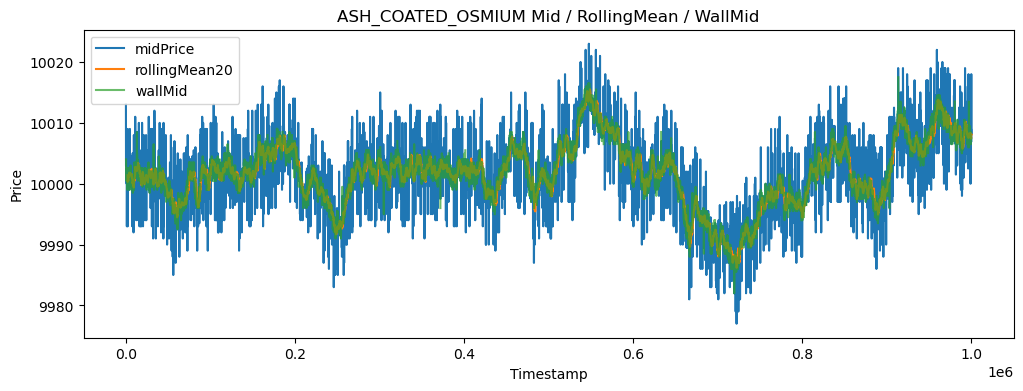

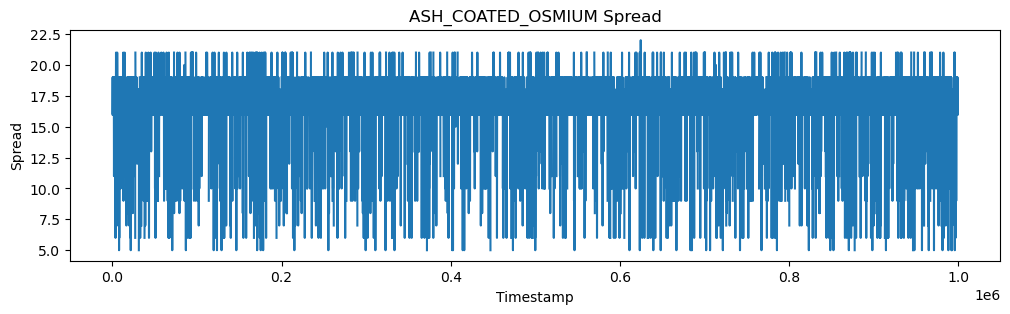

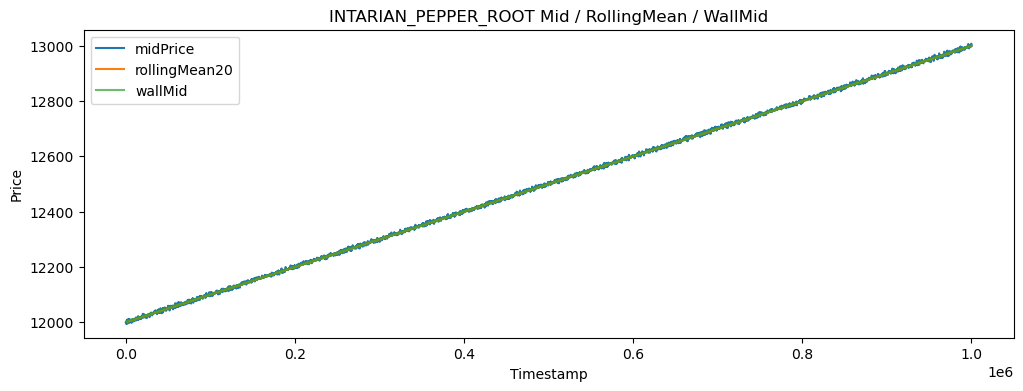

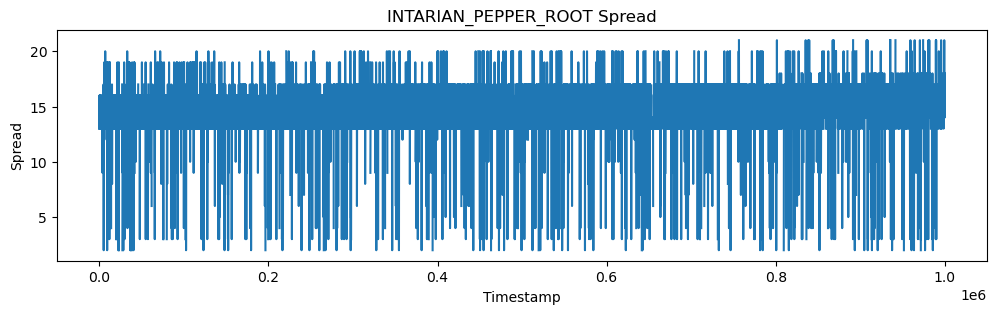

In [66]:
# Plot all products: mid, rolling mean, spread
for product in work["product"].dropna().unique():
    productDf = work[work["product"] == product].copy().sort_values("timestamp")

    plt.figure(figsize=(12, 4))
    plt.plot(productDf["timestamp"], productDf["midPrice"], label="midPrice")
    plt.plot(productDf["timestamp"], productDf["rollingMean20"], label="rollingMean20")
    if "wallMid" in productDf.columns:
        plt.plot(productDf["timestamp"], productDf["wallMid"], label="wallMid", alpha=0.7)
    plt.title(f"{product} Mid / RollingMean / WallMid")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 3))
    plt.plot(productDf["timestamp"], productDf["spread"])
    plt.title(f"{product} Spread")
    plt.xlabel("Timestamp")
    plt.ylabel("Spread")
    plt.show()

## 7. Plot all products quickly

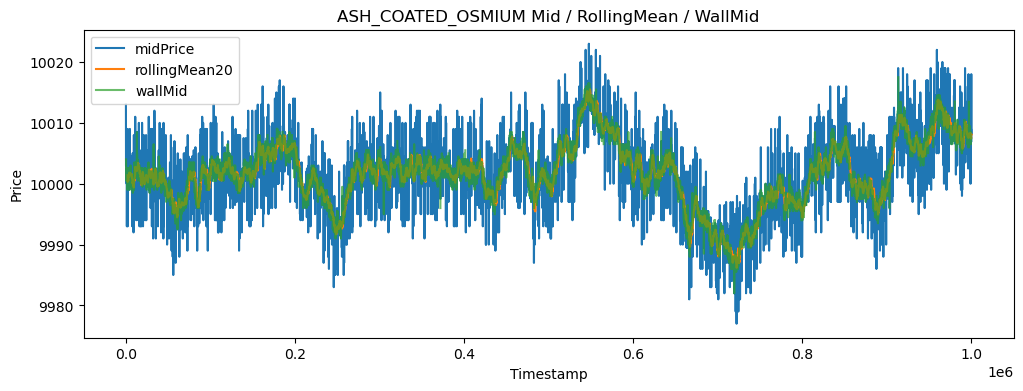

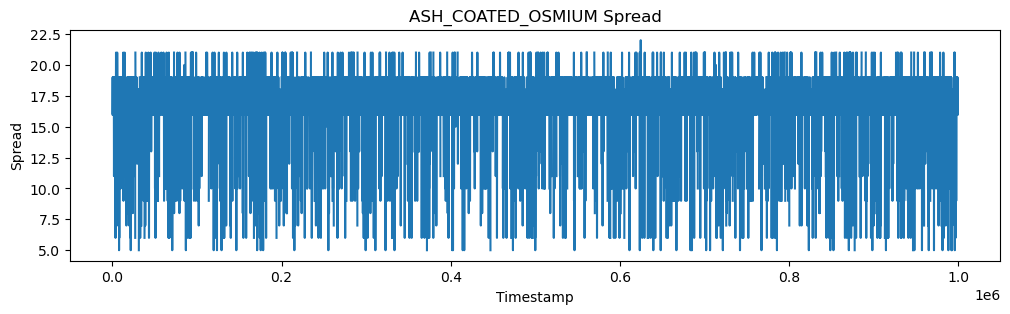

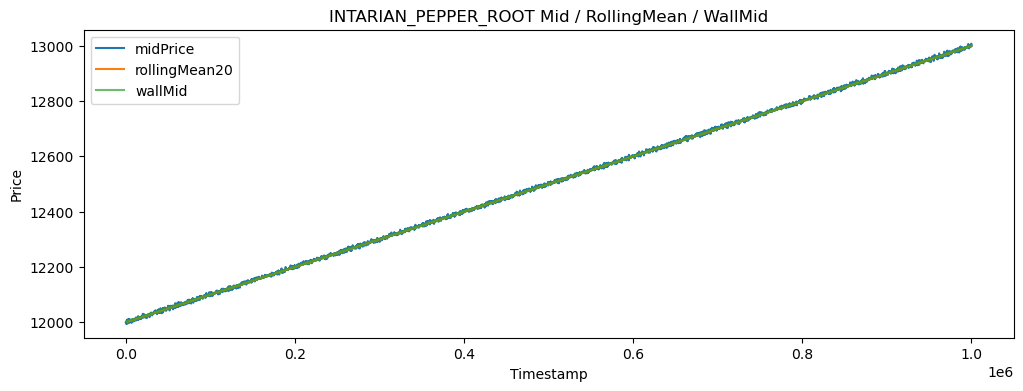

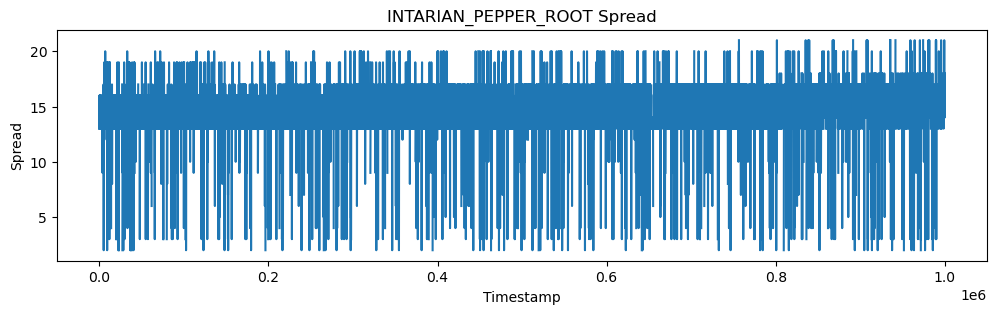

In [67]:
# Plot all products: mid, rolling mean, spread
for product in work["product"].dropna().unique():
    productDf = work[work["product"] == product].copy().sort_values("timestamp")

    plt.figure(figsize=(12, 4))
    plt.plot(productDf["timestamp"], productDf["midPrice"], label="midPrice")
    plt.plot(productDf["timestamp"], productDf["rollingMean20"], label="rollingMean20")
    if "wallMid" in productDf.columns:
        plt.plot(productDf["timestamp"], productDf["wallMid"], label="wallMid", alpha=0.7)
    plt.title(f"{product} Mid / RollingMean / WallMid")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 3))
    plt.plot(productDf["timestamp"], productDf["spread"])
    plt.title(f"{product} Spread")
    plt.xlabel("Timestamp")
    plt.ylabel("Spread")
    plt.show()

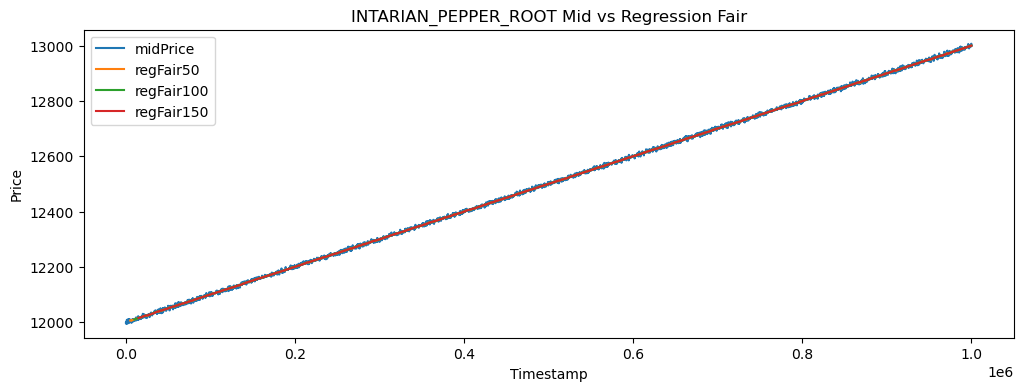

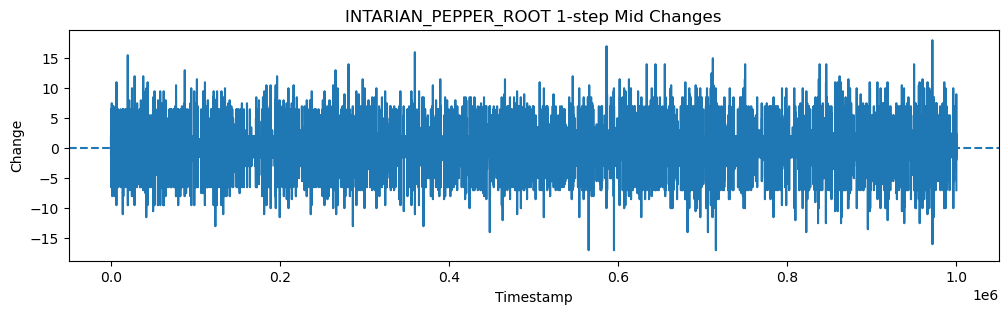


Pepper window 50
Residual std: 2.443657547856192
Residual mean: 0.10015465563109012
Residual z vs next return corr: -0.672544366756729
Slope vs next return corr: -0.0011024695438534597

Pepper window 100
Residual std: 2.3982082931918924
Residual mean: 0.10112939293928844
Residual z vs next return corr: -0.6855869708371711
Slope vs next return corr: 0.000697151643699138

Pepper window 150
Residual std: 2.3861692110261283
Residual mean: 0.10039117446016259
Residual z vs next return corr: -0.6886383264984669
Slope vs next return corr: 0.0005420076987486086

Pepper possible jump counts:
abs(diff) >= 3: 2273
abs(diff) >= 5: 1792
abs(diff) >= 8: 427
abs(diff) >= 10: 183


In [68]:
# Pepper-specific regression diagnostics
pepper = "INTARIAN_PEPPER_ROOT"
pepperDf = work[work["product"] == pepper].copy().sort_values("timestamp").reset_index(drop=True)

if len(pepperDf) > 0:
    windows = [50, 100, 150]

    mids = pepperDf["midPrice"].to_numpy()

    for window in windows:
        regFairs = [np.nan] * len(pepperDf)
        regSlopes = [np.nan] * len(pepperDf)

        for i in range(window, len(pepperDf)):
            y = mids[i-window:i]
            x = np.arange(window)

            xMean = x.mean()
            yMean = y.mean()

            num = ((x - xMean) * (y - yMean)).sum()
            den = ((x - xMean) ** 2).sum()
            slope = 0 if den == 0 else num / den
            intercept = yMean - slope * xMean

            regFairs[i] = slope * (window - 1) + intercept
            regSlopes[i] = slope

        pepperDf[f"regFair{window}"] = regFairs
        pepperDf[f"regResidual{window}"] = pepperDf["midPrice"] - pepperDf[f"regFair{window}"]
        pepperDf[f"regSlope{window}"] = regSlopes
        pepperDf[f"regResidualZ{window}"] = (
            pepperDf[f"regResidual{window}"]
            / pepperDf[f"regResidual{window}"].rolling(100, min_periods=30).std()
        )

    plt.figure(figsize=(12, 4))
    plt.plot(pepperDf["timestamp"], pepperDf["midPrice"], label="midPrice")
    for window in windows:
        plt.plot(pepperDf["timestamp"], pepperDf[f"regFair{window}"], label=f"regFair{window}")
    plt.title("INTARIAN_PEPPER_ROOT Mid vs Regression Fair")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 3))
    plt.plot(pepperDf["timestamp"], pepperDf["midPrice"] - pepperDf["midPrice"].shift(1))
    plt.axhline(0, linestyle="--")
    plt.title("INTARIAN_PEPPER_ROOT 1-step Mid Changes")
    plt.xlabel("Timestamp")
    plt.ylabel("Change")
    plt.show()

    for window in windows:
        print(f"\nPepper window {window}")
        print("Residual std:", pepperDf[f"regResidual{window}"].std())
        print("Residual mean:", pepperDf[f"regResidual{window}"].mean())
        print(
            "Residual z vs next return corr:",
            pepperDf[f"regResidualZ{window}"].corr(pepperDf["nextReturn1"])
        )
        print(
            "Slope vs next return corr:",
            pepperDf[f"regSlope{window}"].corr(pepperDf["nextReturn1"])
        )

    # Jump detector to see regime resets
    pepperDf["jumpAbs"] = pepperDf["midPrice"].diff().abs()
    print("\nPepper possible jump counts:")
    for thr in [3, 5, 8, 10]:
        print(f"abs(diff) >= {thr}: {(pepperDf['jumpAbs'] >= thr).sum()}")

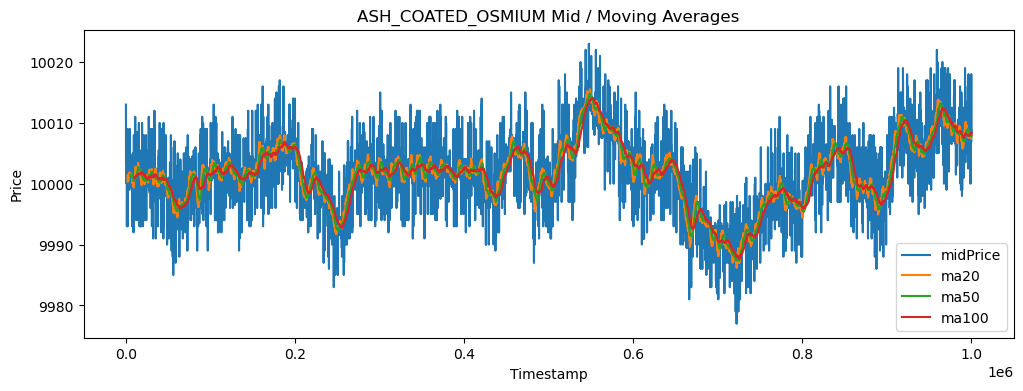

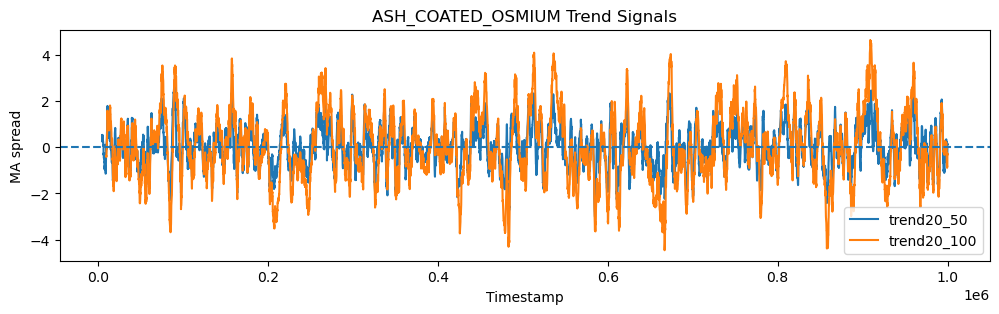

Osmium return autocorr lag1: -0.4870146348384536
Osmium return autocorr lag2: -0.015297488778881926
Osmium momentum5 vs nextReturn corr: -0.48327192854181283
Osmium momentum10 vs nextReturn corr: -0.48253314975477357
Osmium trend20_50 vs nextReturn corr: -0.06310201105101479
Osmium trend20_100 vs nextReturn corr: -0.049427555357204535
Osmium imbalance vs nextReturn corr: 0.3793420715154945


In [69]:
# Osmium-specific diagnostics
# Osmium-specific diagnostics
osmium = "ASH_COATED_OSMIUM"
osmiumDf = work[work["product"] == osmium].copy().sort_values("timestamp").reset_index(drop=True)

if len(osmiumDf) > 0:
    osmiumDf["ma20"] = osmiumDf["midPrice"].rolling(20, min_periods=20).mean()
    osmiumDf["ma50"] = osmiumDf["midPrice"].rolling(50, min_periods=50).mean()
    osmiumDf["ma100"] = osmiumDf["midPrice"].rolling(100, min_periods=100).mean()

    osmiumDf["trend20_50"] = osmiumDf["ma20"] - osmiumDf["ma50"]
    osmiumDf["trend20_100"] = osmiumDf["ma20"] - osmiumDf["ma100"]

    plt.figure(figsize=(12, 4))
    plt.plot(osmiumDf["timestamp"], osmiumDf["midPrice"], label="midPrice")
    plt.plot(osmiumDf["timestamp"], osmiumDf["ma20"], label="ma20")
    plt.plot(osmiumDf["timestamp"], osmiumDf["ma50"], label="ma50")
    plt.plot(osmiumDf["timestamp"], osmiumDf["ma100"], label="ma100")
    plt.title("ASH_COATED_OSMIUM Mid / Moving Averages")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 3))
    plt.plot(osmiumDf["timestamp"], osmiumDf["trend20_50"], label="trend20_50")
    plt.plot(osmiumDf["timestamp"], osmiumDf["trend20_100"], label="trend20_100")
    plt.axhline(0, linestyle="--")
    plt.title("ASH_COATED_OSMIUM Trend Signals")
    plt.xlabel("Timestamp")
    plt.ylabel("MA spread")
    plt.legend()
    plt.show()

    print("Osmium return autocorr lag1:", osmiumDf["return1"].autocorr(lag=1))
    print("Osmium return autocorr lag2:", osmiumDf["return1"].autocorr(lag=2))
    print("Osmium momentum5 vs nextReturn corr:", osmiumDf["momentum5"].corr(osmiumDf["nextReturn1"]))
    print("Osmium momentum10 vs nextReturn corr:", osmiumDf["momentum10"].corr(osmiumDf["nextReturn1"]))
    print("Osmium trend20_50 vs nextReturn corr:", osmiumDf["trend20_50"].corr(osmiumDf["nextReturn1"]))
    print("Osmium trend20_100 vs nextReturn corr:", osmiumDf["trend20_100"].corr(osmiumDf["nextReturn1"]))

    if "imbalance" in osmiumDf.columns:
        print("Osmium imbalance vs nextReturn corr:", osmiumDf["imbalance"].corr(osmiumDf["nextReturn1"]))

In [70]:
# Edge frequency checks against better fair values
edgeRows = []

for product in work["product"].dropna().unique():
    productDf = work[work["product"] == product].copy().sort_values("timestamp").reset_index(drop=True)

    fair = productDf["midPrice"]

    if product == "INTARIAN_PEPPER_ROOT" and "regFair100" in pepperDf.columns:
        tmp = productDf.merge(
            pepperDf[["timestamp", "regFair100"]],
            on="timestamp",
            how="left"
        )
        fair = tmp["regFair100"].combine_first(tmp["midPrice"])

    row = {
        "product": product,
        "ask_le_fair_minus_1_freq": (productDf["ask_price_1"] <= fair - 1).mean(),
        "bid_ge_fair_plus_1_freq": (productDf["bid_price_1"] >= fair + 1).mean(),
        "spread_le_2_freq": (productDf["spread"] <= 2).mean(),
        "spread_ge_4_freq": (productDf["spread"] >= 4).mean(),
    }
    edgeRows.append(row)

edgeDf = pd.DataFrame(edgeRows)
edgeDf

,product,ask_le_fair_minus_1_freq,bid_ge_fair_plus_1_freq,spread_le_2_freq,spread_ge_4_freq
0,ASH_COATED_OSMIUM,0.0000,0.000,0.0000,0.9232
1,INTARIAN_PEPPER_ROOT,0.0155,0.015,0.0068,0.9064


In [71]:
# Passive quote diagnostic with simple fair-distance checks
quoteRows = []

for product in work["product"].dropna().unique():
    productDf = work[work["product"] == product].copy().sort_values("timestamp").reset_index(drop=True)

    fair = productDf["midPrice"]
    if product == "INTARIAN_PEPPER_ROOT" and "regFair100" in pepperDf.columns:
        tmp = productDf.merge(
            pepperDf[["timestamp", "regFair100"]],
            on="timestamp",
            how="left"
        )
        fair = tmp["regFair100"].combine_first(tmp["midPrice"])

    wouldBidAt = productDf["bid_price_1"] + 1
    wouldAskAt = productDf["ask_price_1"] - 1

    row = {
        "product": product,
        "avg_best_bid": productDf["bid_price_1"].mean(),
        "avg_best_ask": productDf["ask_price_1"].mean(),
        "avg_quote_bid": wouldBidAt.mean(),
        "avg_quote_ask": wouldAskAt.mean(),
        "quote_cross_rate": (wouldBidAt >= wouldAskAt).mean(),
        "avg_bid_edge_vs_fair": (fair - wouldBidAt).mean(),
        "avg_ask_edge_vs_fair": (wouldAskAt - fair).mean(),
    }
    quoteRows.append(row)

quoteDf = pd.DataFrame(quoteRows)
quoteDf

,product,avg_best_bid,avg_best_ask,avg_quote_bid,avg_quote_ask,quote_cross_rate,avg_bid_edge_vs_fair,avg_ask_edge_vs_fair
0,ASH_COATED_OSMIUM,9993.521599,10009.705234,9994.521599,10008.705234,0.0000,6.776361,6.773125
1,INTARIAN_PEPPER_ROOT,12492.881918,12508.217983,12493.881918,12507.217983,0.0068,5.974575,6.148257


## 8. Pair relationship checks
Useful once multiple products appear linked.

In [72]:
pivotMid = work.pivot_table(index='timestamp', columns='product', values='midPrice', aggfunc='last')
pivotMid.corr()

product,ASH_COATED_OSMIUM,INTARIAN_PEPPER_ROOT
product,,
ASH_COATED_OSMIUM,1.000000,0.078492
INTARIAN_PEPPER_ROOT,0.078492,1.000000


## 9. Manual classification notes
After you inspect the tables and plots, classify each product:
- anchored / stable
- mean reverting
- trending
- linked to another product
- model-based / derivative
- microstructure-heavy


In [73]:
# Write your notes here as Python comments or plain strings.
notes = {
    # 'AMETHYSTS': 'Looks anchored around 10000, likely fair-value market making',
    # 'STARFRUIT': 'Looks more dynamic, maybe rolling fair value / mean reversion',
}
notes

{}

## 10. Next step
Once you decide the strategy family from this notebook, implement only the surviving logic in `trader.py`.